In [ ]:
import pandas as pd
import statsmodels.api as sm

# Завантаження даних
data = pd.read_excel('Модель.xlsx')
X = data.drop(columns=['Country','GDP per person employed (constant 2021 PPP $)', 'Agree "Most people can be trusted"', 'Rule of Law index'])
Y = data['GDP per person employed (constant 2021 PPP $)']

# Додаємо константу для моделі
X = sm.add_constant(X)

# Створюємо та натренуємо модель OLS
model = sm.OLS(Y, X).fit()

# Виводимо підсумкову статистику
print(model.summary())

                                          OLS Regression Results                                         
Dep. Variable:     GDP per person employed (constant 2021 PPP $)   R-squared:                       0.826
Model:                                                       OLS   Adj. R-squared:                  0.821
Method:                                            Least Squares   F-statistic:                     166.8
Date:                                           Mon, 11 Nov 2024   Prob (F-statistic):           8.08e-65
Time:                                                   01:31:32   Log-Likelihood:                -2035.6
No. Observations:                                            182   AIC:                             4083.
Df Residuals:                                                176   BIC:                             4102.
Df Model:                                                      5                                         
Covariance Type:                              

In [ ]:
from scipy.stats import f

# Отримуємо значення F-статистики та кількість ступенів свободи моделі
f_statistic = model.fvalue
dof_model = X.shape[1] - 1

# Кількість ступенів свободи для залишкової суми квадратів
dof_resid = model.df_resid

# Обчислюємо ймовірність, що отримане значення F-статистики може бути досягнуте випадково
p_value = f.sf(f_statistic, dof_model, dof_resid)

# Виводимо результат
print("F-статистика:", f_statistic)
print("Кількість ступенів свободи моделі:", dof_model)
print("Кількість ступенів свободи залишкової суми квадратів:", dof_resid)
print("Ймовірність:", p_value)

F-статистика: 166.78117406624963
Кількість ступенів свободи моделі: 5
Кількість ступенів свободи залишкової суми квадратів: 176.0
Ймовірність: 8.081013556954884e-65


In [ ]:
from scipy.stats import f

# Задаємо рівень значущості alpha
alpha = 0.05

# Визначаємо критичне значення F-статистики для вказаного рівня значущості та ступенів свободи
critical_value = f.ppf(1 - alpha, dof_model, dof_resid)

critical_value

2.2654642592627003

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # Створюємо датафрейм для зберігання результатів
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Застосовуємо функцію до незалежних змінних X
vif_results = calculate_vif(X)

# Виводимо результати
print(vif_results)

                                             Feature        VIF
0                                              const  28.797426
1           Ecological Footprint (HectaresPerCapita)   2.172104
2              % Medium and high-tech exports in GDP   1.538993
3                       Global Innovation Index 2023   2.889943
4                            Electricity_consumption   2.379711
5  Mortality caused by road traffic injury (per 1...   1.892570


In [ ]:
import statsmodels.stats.api as sms

# Перевірка гетероскедастичності за допомогою тесту Бройша-Пагана
breusch_pagan_test = sms.het_breuschpagan(model.resid, model.model.exog)
print("p-value тесту Бройша-Пагана:", breusch_pagan_test[1])


p-value тесту Бройша-Пагана: 0.008481057653345598


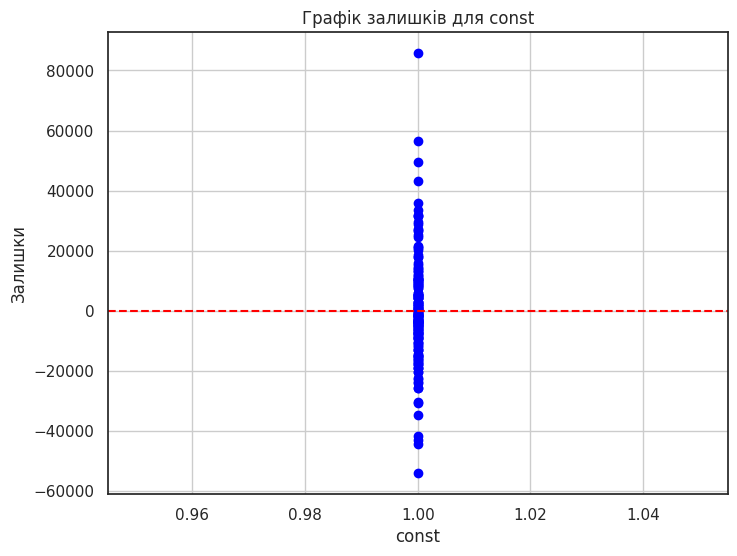

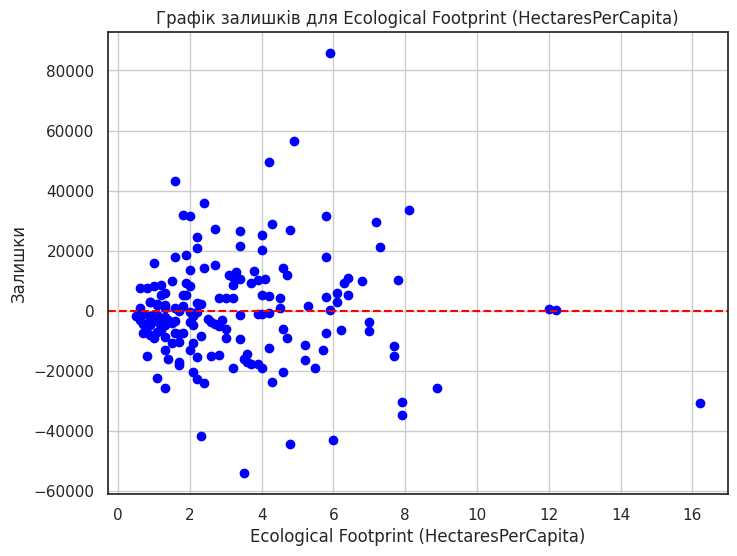

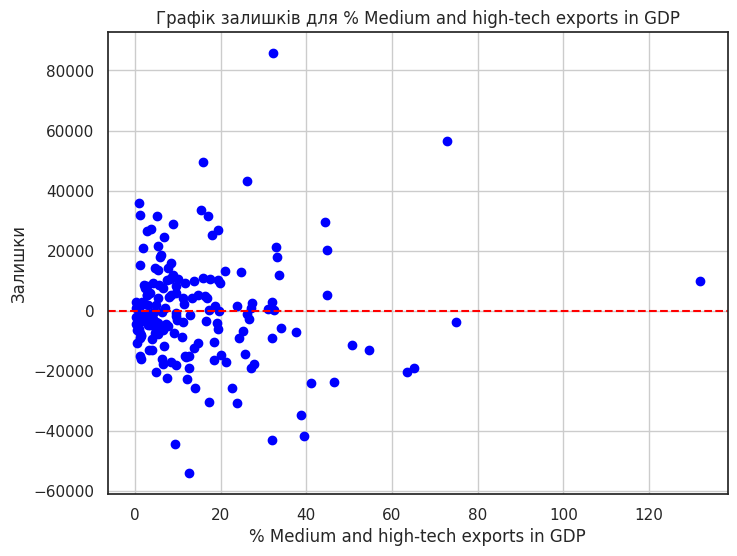

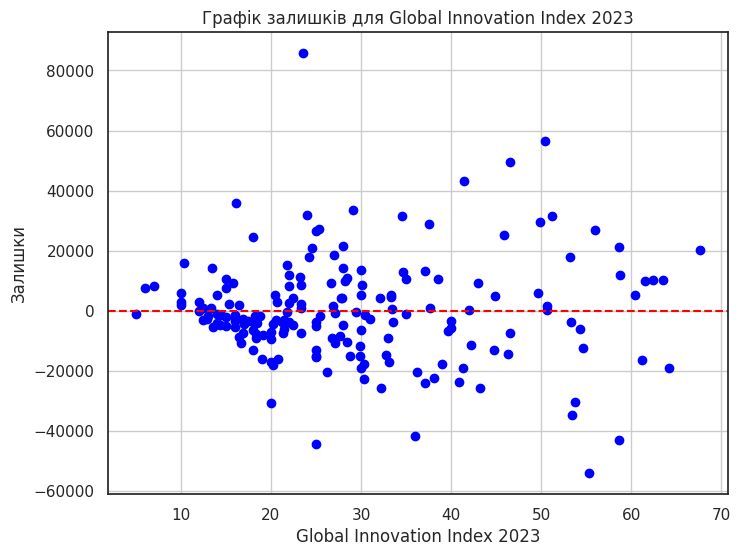

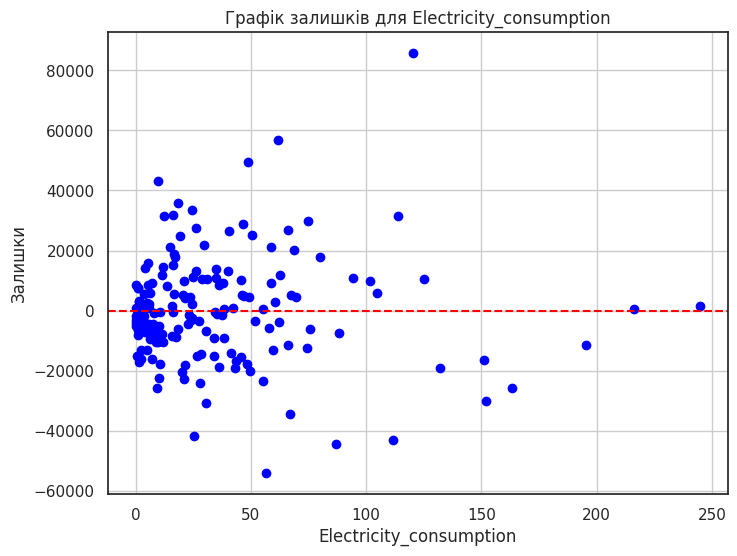

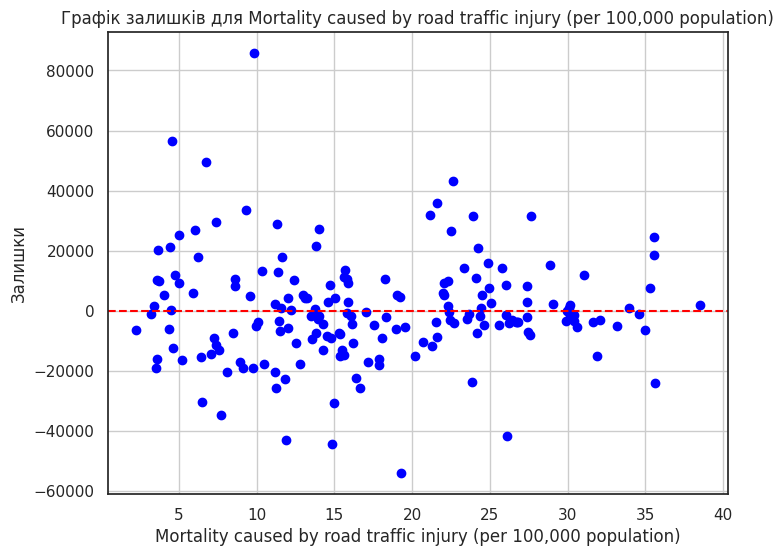

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Обчислюємо залишки
residuals = model.resid

# Побудова графіків залишків для кожного предиктора
for column in X.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(X[column], residuals, color='blue')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f"Графік залишків для {column}")
    plt.xlabel(column)
    plt.ylabel('Залишки')
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Завантаження даних
data = pd.read_excel('Модель.xlsx')

# Додавання константи для коректного розрахунку VIF
X = sm.add_constant(X)

# Розрахунок VIF для кожної незалежної змінної
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Виведення результату
print("VIF для кожної незалежної змінної:")
print(vif_data)


VIF для кожної незалежної змінної:
                                            Variable        VIF
0                                              const  28.797426
1           Ecological Footprint (HectaresPerCapita)   2.172104
2              % Medium and high-tech exports in GDP   1.538993
3                       Global Innovation Index 2023   2.889943
4                            Electricity_consumption   2.379711
5  Mortality caused by road traffic injury (per 1...   1.892570


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms

# Завантаження даних
data = pd.read_excel('Модель.xlsx')

# Вибір незалежних змінних та цільової змінної
X = data.drop(columns=['Country', 'GDP per person employed (constant 2021 PPP $)', 'Agree "Most people can be trusted"', 'Rule of Law index'])
Y = data['GDP per person employed (constant 2021 PPP $)']

# Додавання константи
X = sm.add_constant(X)

# Побудова моделі OLS
model = sm.OLS(Y, X).fit()

# Тест Бройша-Пагана
breusch_pagan_test = sms.het_breuschpagan(model.resid, model.model.exog)

# Виведення результатів
print("Breusch-Pagan test p-value:", breusch_pagan_test[1])
print("Breusch-Pagan test LM statistic:", breusch_pagan_test[0])
print("Breusch-Pagan test LM p-value:", breusch_pagan_test[2])
print("Breusch-Pagan test F-statistic:", breusch_pagan_test[3])

Breusch-Pagan test p-value: 0.008481057653345598
Breusch-Pagan test LM statistic: 15.484441448846264
Breusch-Pagan test LM p-value: 3.273281750617604
Breusch-Pagan test F-statistic: 0.007496371945794045


In [ ]:
import statsmodels.api as sm

# Побудова моделі OLS із робастними стандартними помилками
model_robust = sm.OLS(Y, X).fit(cov_type='HC3')

# Виведення підсумкової статистики з робастними стандартними помилками
print(model_robust.summary())

                                          OLS Regression Results                                         
Dep. Variable:     GDP per person employed (constant 2021 PPP $)   R-squared:                       0.826
Model:                                                       OLS   Adj. R-squared:                  0.821
Method:                                            Least Squares   F-statistic:                     139.8
Date:                                           Mon, 11 Nov 2024   Prob (F-statistic):           2.30e-59
Time:                                                   02:51:24   Log-Likelihood:                -2035.6
No. Observations:                                            182   AIC:                             4083.
Df Residuals:                                                176   BIC:                             4102.
Df Model:                                                      5                                         
Covariance Type:                              

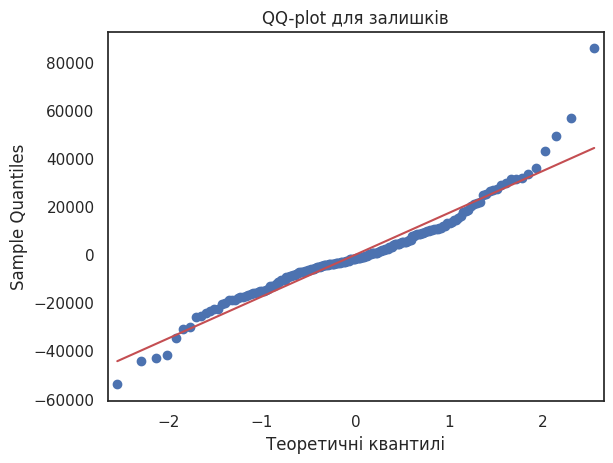

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats

# QQ-plot
sm.qqplot(residuals, line='s')
plt.title('QQ-plot для залишків')
plt.xlabel('Теоретичні квантилі')
plt.show()

In [ ]:
# Отримання індексів викидів
outlier_residuals = model.get_influence().resid_studentized_external > 2  # Визначення викидів за критерієм

# Отримання значень залежної змінної Y для викидів
outlier_y_values = data.loc[outlier_residuals, 'GDP per person employed (constant 2021 PPP $)']

# Виведення відповідних значень Y
print("Значення Y, що відповідають викидам:")
print(outlier_y_values)

Значення Y, що відповідають викидам:
1     182654.460509
2     174687.122968
9     129004.575592
27     94106.190980
64     57463.539168
Name: GDP per person employed (constant 2021 PPP $), dtype: float64


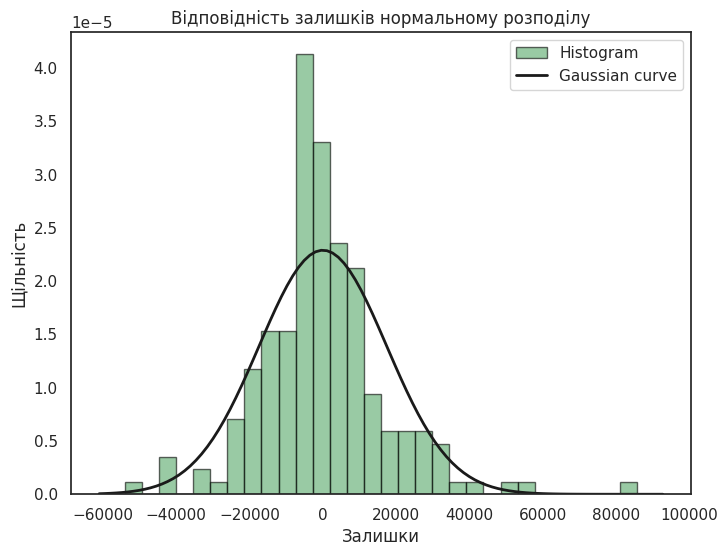

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g', edgecolor='black', label='Histogram')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(residuals), np.std(residuals))
plt.plot(x, p, 'k', linewidth=2, label='Gaussian curve')

plt.title('Відповідність залишків нормальному розподілу')
plt.xlabel('Залишки')
plt.ylabel('Щільність')
plt.legend()
plt.show()

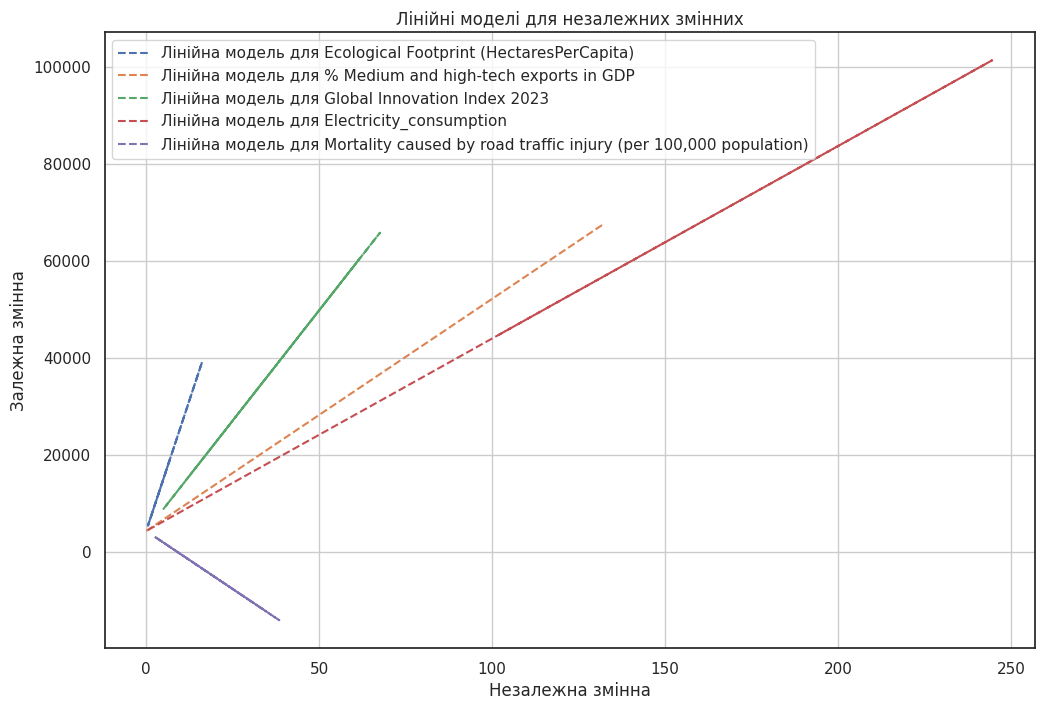

In [ ]:
import matplotlib.pyplot as plt

# Отримання коефіцієнтів регресії
coefficients = model.params

# Отримання назв незалежних змінних
independent_variables = X.columns

# Побудова ліній для кожної незалежної змінної
plt.figure(figsize=(12, 8))

for variable in independent_variables:
    if variable != 'const':  # Пропустити константу
        slope = coefficients[variable]
        constant = coefficients['const']
        X_values = X[variable]
        predicted_Y = slope * X_values + constant
        plt.plot(X_values, predicted_Y, label=f'Лінійна модель для {variable}', linestyle='--')

# Додавання легенди та маркерів осей
plt.legend()
plt.xlabel('Незалежна змінна')
plt.ylabel('Залежна змінна')
plt.title('Лінійні моделі для незалежних змінних')
plt.grid(True)
plt.show()

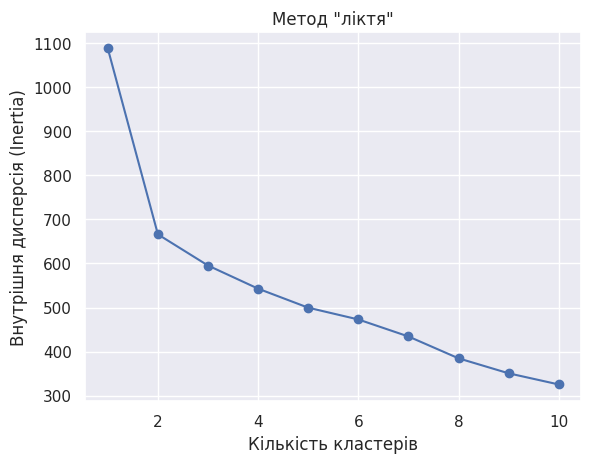

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Зчитуємо дані з файлу Excel
data = pd.read_excel('Вих Дані.xlsx')

# Виключаємо стовбець "Country"
data_for_clustering = data.drop(columns=['Country'])

# Стандартизуємо дані
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# Створюємо пустий список для збереження значень внутрішньої дисперсії
inertia = []

# Пробуємо різні кількості кластерів
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Побудова графіка методу "ліктя"
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Кількість кластерів')
plt.ylabel('Внутрішня дисперсія (Inertia)')
plt.title('Метод "ліктя"')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

linkage_matrix = linkage(scaled_data, method='ward')

# Визначаємо оптимальну кількість кластерів
max_d = 10  # максимальна відстань між кластерами
clusters = fcluster(linkage_matrix, max_d, criterion='distance')

num_clusters = len(np.unique(clusters))
print("Оптимальна кількість кластерів:", num_clusters)

Оптимальна кількість кластерів: 4


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.drop(columns=['Country']))

num_clusters = 4
# Побудова моделі k-means з використанням попередньої стандартизації
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(scaled_data)

# Додавання міток кластерів до даних
data_with_clusters = data.assign(Cluster=kmeans.labels_)

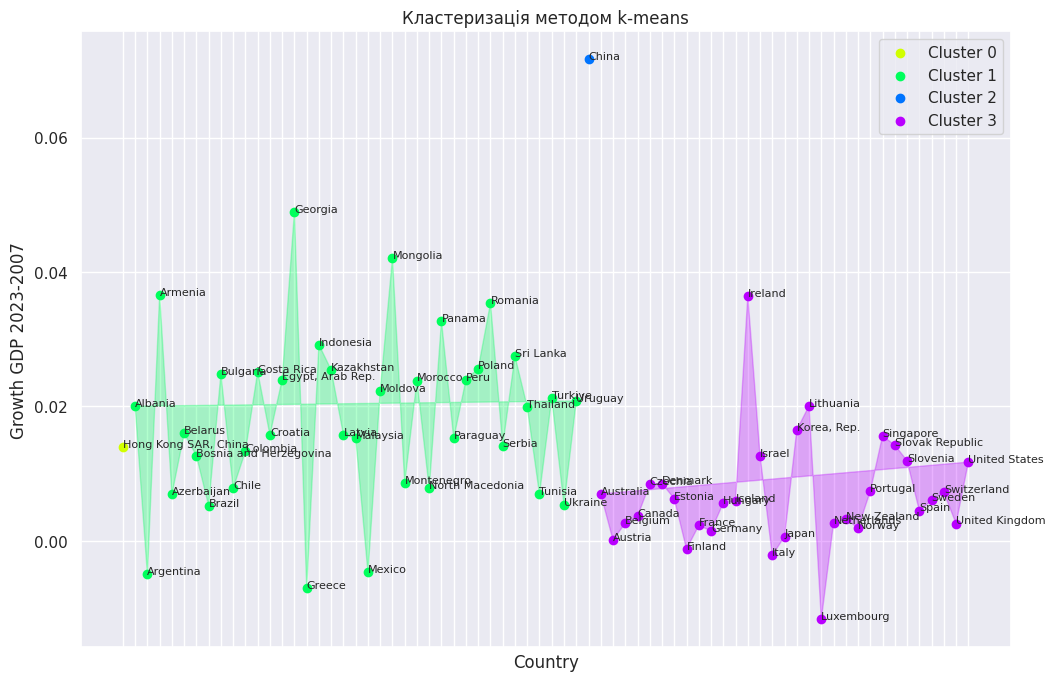

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Встановлення стилю Seaborn
sns.set_style("darkgrid")

# Створення кольорової палітри для кластерів
palette = sns.color_palette("hsv", num_clusters)

# Побудова графіку
plt.figure(figsize=(12, 8))
for cluster_num in range(num_clusters):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_num]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], color=palette[cluster_num], label=f'Cluster {cluster_num}')

    # Додавання позначок "Country" до кожного кластера зі зменшеним розміром шрифту
    for i, txt in enumerate(cluster_data['Country']):
        plt.annotate(txt, (cluster_data.iloc[i, 0], cluster_data.iloc[i, 1]), fontsize=8)

    # Зазначення кожного кластера зонами
    hull = plt.fill(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], color=palette[cluster_num], alpha=0.3, closed=True)

plt.title('Кластеризація методом k-means')
plt.xlabel(data_with_clusters.columns[0])
plt.ylabel(data_with_clusters.columns[1])

# Відключення показу позначок на осі x
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Ініціалізуємо PCA зі збереженням 80% дисперсії
pca = PCA(n_components=0.9)

# Застосовуємо PCA до даних
pca.fit(data_with_clusters.drop(columns=['Country', 'Cluster']))

num_components = pca.n_components_
print(f'Кількість компонент для пояснення мінімум 90% дисперсії: {num_components}')

Кількість компонент для пояснення мінімум 90% дисперсії: 3


<ipython-input-19-c87a500239bc>:28: RuntimeWarning: Degrees of freedom <= 0 for slice
  covariance_matrix = np.cov(cluster_data.T)
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


LinAlgError: Eigenvalues did not converge

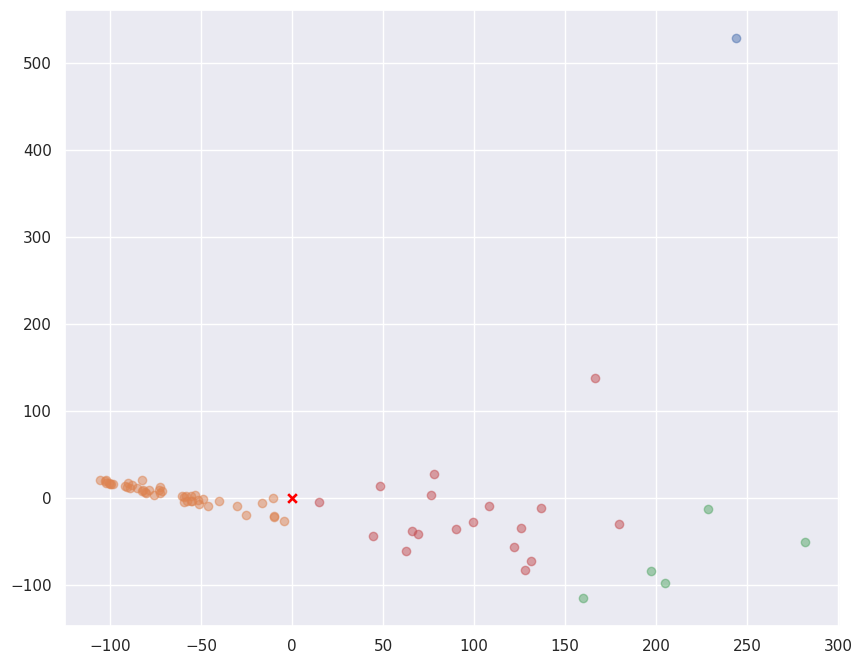

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Завантаження даних
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country"
data_without_country = data.drop(columns=["Country"])

# Виконуємо PCA з двома компонентами
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_without_country)

# Кластеризація методом к-середніх на 4 кластери
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_without_country)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Вираховуємо матрицю коваріації кожного кластера
covariances = []
for cluster in range(4):
    cluster_data = data_without_country[labels == cluster]
    covariance_matrix = np.cov(cluster_data.T)
    covariances.append(covariance_matrix)

# Створення DataFrame з головними компонентами та мітками кластерів
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
principal_df['Cluster'] = labels

# Графік розсіювання з відображенням кластерів та центрів кластерів
plt.figure(figsize=(10, 8))
for cluster in range(4):
    cluster_data = principal_df[principal_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster}', alpha=0.5)

# Відображення центроїдів
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', color='red', label='Centroids')

for cluster, covariance in enumerate(covariances):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))  # Використовуємо перші два значення eigenvectors
    width, height = 2 * np.sqrt(2) * np.sqrt(eigenvalues[:2])
    ellipse = Ellipse(xy=centroids[cluster], width=width, height=height, angle=angle, edgecolor='black', facecolor='none')
    plt.gca().add_patch(ellipse)


plt.title('Scatter Plot of PCA with Clusters and Centroids')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True)
plt.show()

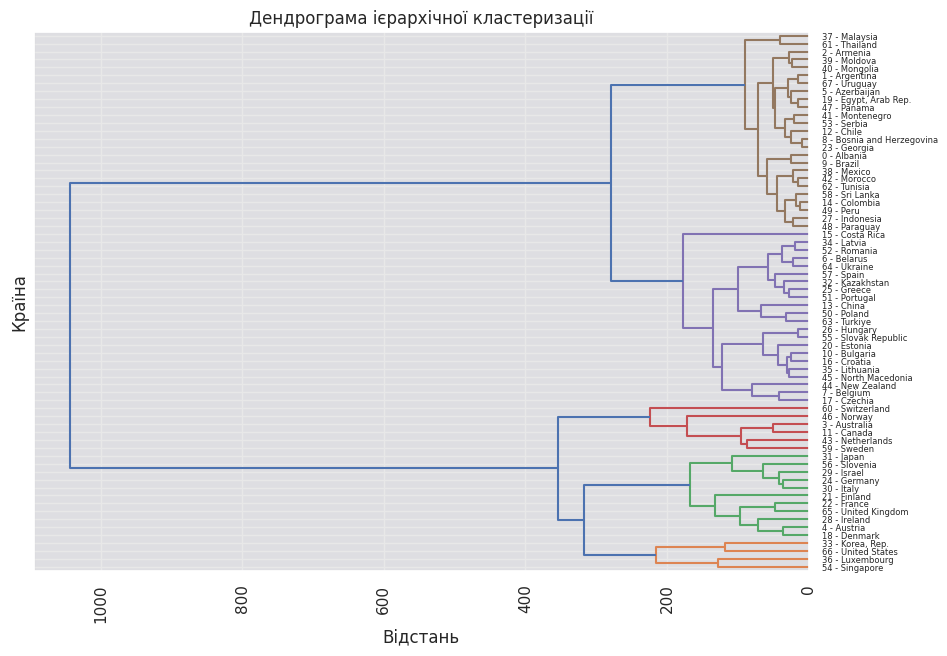

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Зчитуємо дані з Excel-файлу
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country", якщо він присутній
data_without_country = data.drop(columns=["Country"])

# Додаємо стовпець "Country" до відображення кластеризації
data_with_country = data.copy()

# Стандартизація даних
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_without_country)

# Виконуємо ієрархічну кластеризацію методом к-середніх
num_clusters = 4
model = AgglomerativeClustering(n_clusters=num_clusters, linkage='ward')
cluster_labels = model.fit_predict(data_without_country)

# Побудова дендрограми з використанням індексів даних
linked = linkage(data_without_country, 'ward')
# Створення списку міток у потрібному форматі
labels = ["{} - {}".format(idx, country) for idx, country in zip(data.index, data_with_country['Country'])]

# Побудова дендрограми з використанням створеного списку міток
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='left',  # Зміна орієнтації на горизонтальну
           labels=labels,  # Використовуємо список міток у потрібному форматі
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=250)

plt.title('Дендрограма ієрархічної кластеризації')
plt.xlabel('Відстань')
plt.ylabel('Країна')
plt.xticks(rotation=90)  # Повернення міток на горизонтальний вигляд

# Додати фон
plt.axhspan(0, 1000, color='lightgrey', alpha=0.5)

# Змінити кольори кластерів
for i, d in zip(range(1, len(linked)+1), linked[:, 2]):
    if d < 450:
        plt.axvline(x=d, color='c', linestyle='')

# Зберегти графік у форматі PDF
plt.savefig('dendrogram.pdf')

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

# Зчитуємо дані з Excel-файлу
data = pd.read_excel("Вих Дані.xlsx")

# Видаляємо стовпець "Country", якщо він присутній
data_without_country = data.drop(columns=["Country"])

# Отримуємо список країн
countries = data['Country'].values

# Створюємо матрицю відстаней на основі ієрархічної кластеризації
linked = linkage(data_without_country, 'ward')
distance_matrix = squareform(pdist(data_without_country, metric='euclidean'))

# Знаходимо індекс України в списку країн
ukraine_index = data[data['Country'] == 'Ukraine'].index[0]

# Отримуємо відстані від України до всіх інших країн
distances_to_ukraine = distance_matrix[ukraine_index]

# Знаходимо індекси 10 найменших відстаней (окрім самої України)
closest_indices = np.argsort(distances_to_ukraine)[1:21]

# Отримуємо назви країн з цими індексами та відповідні відстані
closest_countries = [(countries[i], distances_to_ukraine[i]) for i in closest_indices]

# Перетворюємо у таблицю для зручності
closest_countries_df = pd.DataFrame(closest_countries, columns=['Country', 'Distance'])

print(closest_countries_df)

                   Country   Distance
0                  Belarus  22.072907
1                  Armenia  24.887648
2                   Latvia  25.725734
3               Kazakhstan  28.134369
4                  Romania  30.268297
5                  Georgia  30.801925
6   Bosnia and Herzegovina  33.912881
7                 Mongolia  34.607615
8                   Serbia  34.782760
9                 Bulgaria  35.585832
10                 Moldova  35.701568
11              Montenegro  35.775360
12                  Greece  36.575263
13                  Brazil  36.756517
14              Azerbaijan  37.153170
15                   Chile  38.028264
16                Portugal  38.486955
17                 Croatia  39.833863
18                 Tunisia  40.262894
19               Argentina  40.602190


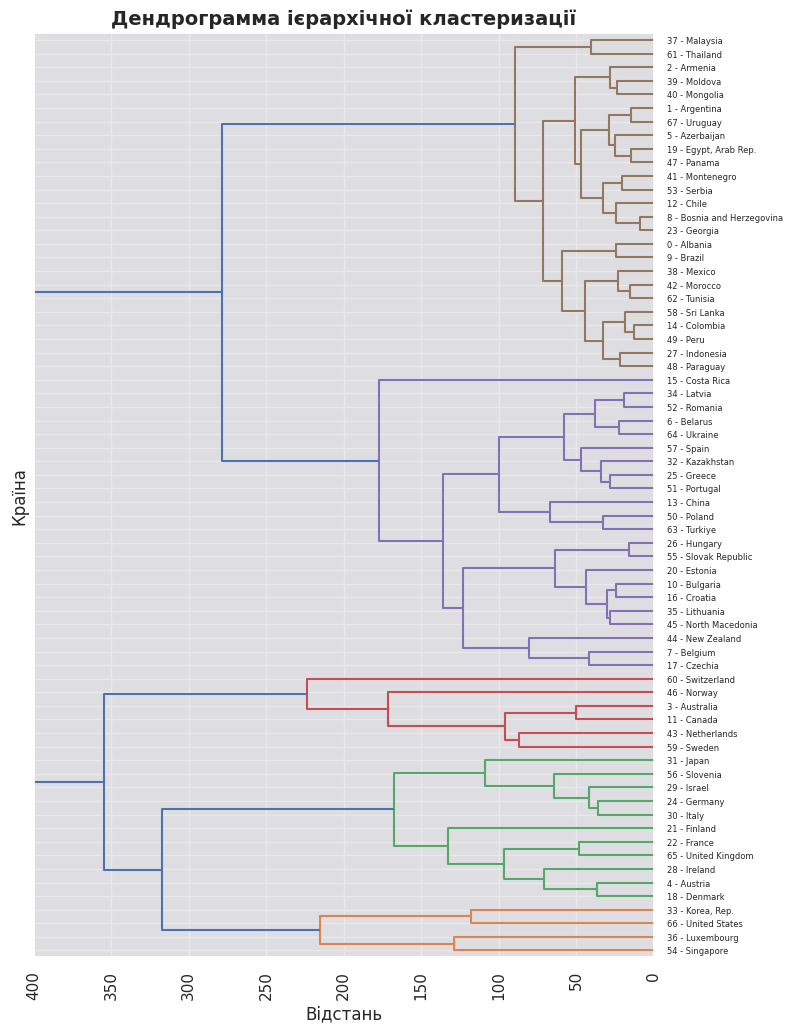

In [ ]:
plt.figure(figsize=(8, 12))
dendrogram(linked,
           orientation='left',  # Зміна орієнтації на горизонтальну
           labels=labels,  # Використовуємо список міток у потрібному форматі
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=250)

plt.title('Дендрограмма ієрархічної кластеризації', fontdict={'fontsize': 14, 'fontweight': 'bold'})  # Змінити шрифт заголовку
plt.xlabel('Відстань', fontdict={'fontsize': 12})  # Змінити шрифт назви осі X
plt.ylabel('Країна', fontdict={'fontsize': 12})  # Змінити шрифт назви осі Y
plt.xticks(rotation=90)  # Повернення міток на горизонтальний вигляд

# Змінити масштаб для проміжку відстаней 500-1000
plt.xlim(400, 0)

# Додати фон
plt.axhspan(0, 1000, color='lightgrey', alpha=0.5)

# Змінити кольори кластерів
for i, d in zip(range(1, len(linked)+1), linked[:, 2]):
    if 200 < d < 450:
        plt.axvline(x=d, color='c', linestyle='')

# Зберегти графік у форматі PDF
plt.savefig('dendrogram1.pdf')

plt.show()

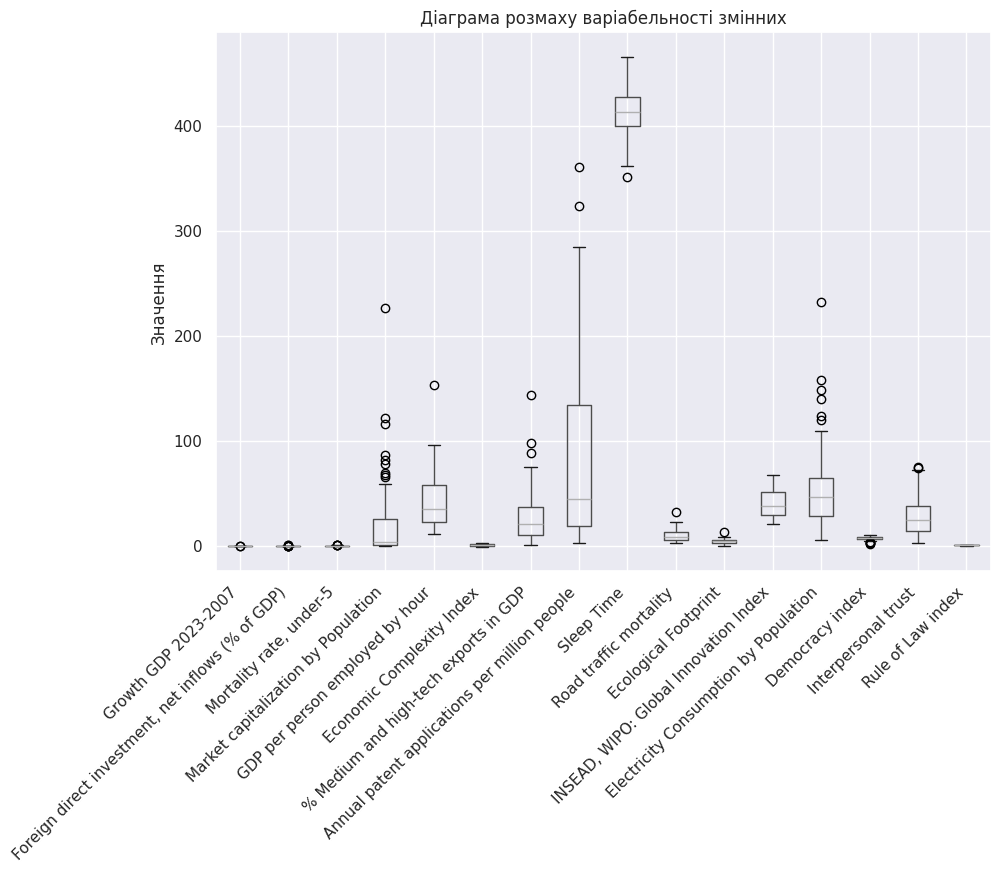

In [ ]:
plt.figure(figsize=(10, 7))
data_without_country.boxplot()
plt.title('Діаграма розмаху варіабельності змінних')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Значення')
plt.show()

In [ ]:
# Знаходження першого та третього квартилю
Q1 = data_without_country.quantile(0.25)
Q3 = data_without_country.quantile(0.75)

# Обчислення міжквартильного діапазону
IQR = Q3 - Q1

# Знаходження викидів за межами міжквартильного діапазону для кожної змінної
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = (data_without_country < lower_bound) | (data_without_country > upper_bound)

# Виведення викидів за межами розмаху для кожної змінної
print("Викиди за межами розмаху:")
for column in outliers.columns:
    print(f"Змінна '{column}':")
    print(outliers[outliers[column]].head(10))
    print()

Викиди за межами розмаху:
Змінна 'Growth GDP 2023-2007':
    Growth GDP 2023-2007  Foreign direct investment, net inflows (% of GDP)  \
13                  True                                              False   
23                  True                                              False   

    Mortality rate, under-5  Market capitalization by Population  \
13                    False                                False   
23                    False                                False   

    GDP per person employed by hour  Economic Complexity Index  \
13                            False                      False   
23                            False                      False   

    % Medium and high-tech exports in GDP  \
13                                  False   
23                                  False   

    Annual patent applications per million people  Sleep Time  \
13                                          False       False   
23                                 

In [ ]:
# Додаємо стовпець з мітками кластерів до даних
data_with_clusters = data_without_country.copy()
data_with_clusters['Cluster'] = cluster_labels

# Обчислюємо середні значення кожного показника для кожного кластера
cluster_means = data_with_clusters.groupby('Cluster').mean()

# Виводимо середні значення кожного показника для кожного кластера
print("Середні значення кожного показника для кожного кластера:")
print(cluster_means)

Середні значення кожного показника для кожного кластера:
         GDP per person employed by hour (C 2017 PPP $)  \
Cluster                                                   
0                                             82.155913   
1                                             21.047288   
2                                             59.238235   
3                                             41.980601   

         Market capitalization by P  Economic Complexity Index (ECI)  \
Cluster                                                                
0                         93.083953                         1.710000   
1                          2.303027                         0.055952   
2                         47.735835                         1.308824   
3                         13.099990                         1.046154   

         % Medium and high-tech exports in GDP  % Net Migration by 1000  \
Cluster                                                                   
0    

In [ ]:
# Додаємо мітки кластерів до даних
data_with_country['Cluster'] = cluster_labels

# Групуємо дані за кластерними мітками та виводимо унікальні значення Country для кожного кластеру
for cluster_num in range(num_clusters):
    print(f"Кластер {cluster_num + 1}:")
    countries_in_cluster = data_with_country[data_with_country['Cluster'] == cluster_num]['Country'].unique()
    print(", ".join(countries_in_cluster))
    print()

Кластер 1:
Albania, Argentina, Armenia, Azerbaijan, Belarus, Belgium, Bosnia and Herzegovina, Brazil, Bulgaria, Chile, China, Colombia, Costa Rica, Croatia, Czechia, Egypt, Arab Rep., Estonia, Georgia, Greece, Hungary, Indonesia, Kazakhstan, Latvia, Lithuania, Malaysia, Mexico, Moldova, Mongolia, Montenegro, Morocco, New Zealand, North Macedonia, Panama, Paraguay, Peru, Poland, Portugal, Romania, Serbia, Slovak Republic, Spain, Sri Lanka, Thailand, Tunisia, Turkiye, Ukraine, Uruguay

Кластер 2:
Korea, Rep., Luxembourg, Singapore, United States

Кластер 3:
Australia, Canada, Netherlands, Norway, Sweden, Switzerland

Кластер 4:
Austria, Denmark, Finland, France, Germany, Ireland, Israel, Italy, Japan, Slovenia, United Kingdom



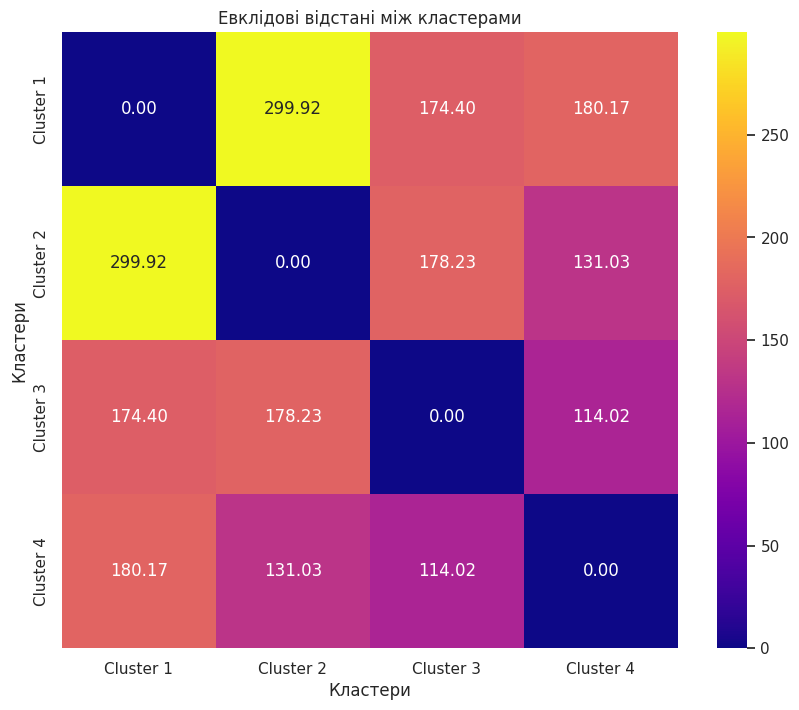

In [ ]:
import seaborn as sns
import numpy as np

# Обчислюємо матрицю відстаней між кластерами
distance_matrix = np.zeros((num_clusters, num_clusters))
for i in range(num_clusters):
    for j in range(num_clusters):
        # Обчислення евклідової відстані між центрами кластерів
        center_i = data_without_country[cluster_labels == i].mean(axis=0)
        center_j = data_without_country[cluster_labels == j].mean(axis=0)
        distance_matrix[i, j] = np.linalg.norm(center_i - center_j)

# Відображення матриці відстаней як теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=True, cmap='plasma', fmt=".2f", square=True,
            xticklabels=[f"Cluster {i+1}" for i in range(num_clusters)],
            yticklabels=[f"Cluster {i+1}" for i in range(num_clusters)])
plt.title('Евклідові відстані між кластерами')
plt.xlabel('Кластери')
plt.ylabel('Кластери')
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Створюємо пустий рядок для збереження результатів
results_str = ""

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Додаємо результати до рядка
    results_str += f"{column}\t{f_statistic}\t{len(groups) - 1}\t{p_value}\t{len(data_without_country) - len(groups)}\n"

# Виводимо результати
print("Variable\tBetween SS\tdf\tWithin SS\tdf\tF signif.\tp")
print(results_str)

Variable	Between SS	df	Within SS	df	F signif.	p
Growth GDP 2023-2007	3.428158056442358	3	0.022186326040231172	64
Foreign direct investment, net inflows (% of GDP)	0.17275091850799754	3	0.9144384410283019	64
Mortality rate, under-5	7.933660356721881	3	0.00014097116904596125	64
Market capitalization by Population	51.76022920689121	3	4.203006176565278e-17	64
GDP per person employed by hour	33.64043402227303	3	3.5681123813632684e-13	64
Economic Complexity Index	14.524234400639578	3	2.5496603629835347e-07	64
% Medium and high-tech exports in GDP	5.641112539774173	3	0.0017089491153970602	64
Annual patent applications per million people	172.83726947860458	3	1.2405425444080098e-30	64
Sleep Time	3.6091480159966483	3	0.017898753441062797	64
Road traffic mortality	11.495290963349516	3	4.0154639851538754e-06	64
Ecological Footprint	8.144347727538824	3	0.00011302294089994165	64
INSEAD, WIPO: Global Innovation Index	39.62685529633847	3	1.3441166593594352e-14	64
Electricity Consumption by Population	

In [ ]:
from scipy.stats import f_oneway

# Створюємо порожні списки для збереження результатів
between_SS_values = []
within_SS_values = []

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Додаємо значення Between SS та Within SS до відповідних списків
    between_SS_values.append(f_statistic)
    within_SS_values.append(p_value)

# Виводимо значення міжгрупової та внутрішньогрупової дисперсій для кожної ознаки
print("Variable\tBetween Group Variance\tWithin Group Variance")
for i, column in enumerate(data_without_country.columns):
    print(f"{column}\t{between_SS_values[i]:.3f}\t{within_SS_values[i]}")

Variable	Between Group Variance	Within Group Variance
Growth GDP 2023-2007	3.428	0.022186326040231172
Foreign direct investment, net inflows (% of GDP)	0.173	0.9144384410283019
Mortality rate, under-5	7.934	0.00014097116904596125
Market capitalization by Population	51.760	4.203006176565278e-17
GDP per person employed by hour	33.640	3.5681123813632684e-13
Economic Complexity Index	14.524	2.5496603629835347e-07
% Medium and high-tech exports in GDP	5.641	0.0017089491153970602
Annual patent applications per million people	172.837	1.2405425444080098e-30
Sleep Time	3.609	0.017898753441062797
Road traffic mortality	11.495	4.0154639851538754e-06
Ecological Footprint	8.144	0.00011302294089994165
INSEAD, WIPO: Global Innovation Index	39.627	1.3441166593594352e-14
Electricity Consumption by Population	19.561	4.108136198590326e-09
Democracy index	12.228	2.0170745319089567e-06
Interpersonal trust	22.364	5.08430626406896e-10
Rule of Law index	9.883	1.9209069622069362e-05


In [ ]:
from scipy.stats import f_oneway

# Створюємо пустий словник для збереження результатів
results = {}

# Для кожного стовпця вихідних даних
for column in data_without_country.columns:
    # Створюємо список груп для поточного стовпця
    groups = [data_without_country[column].iloc[cluster_labels == i] for i in range(num_clusters)]

    # Застосовуємо дисперсійний аналіз
    f_statistic, p_value = f_oneway(*groups)

    # Зберігаємо результати в словнику
    results[column] = {'F statistic': f_statistic, 'p-value': p_value}

# Виводимо результати для кожного показника
for column, result in results.items():
    print(f"Results for {column}:")
    print("F statistic:", result['F statistic'])
    print("p-value:", result['p-value'])
    print()

Results for Growth GDP 2023-2007:
F statistic: 3.428158056442358
p-value: 0.022186326040231172

Results for Foreign direct investment, net inflows (% of GDP):
F statistic: 0.17275091850799754
p-value: 0.9144384410283019

Results for Mortality rate, under-5:
F statistic: 7.933660356721881
p-value: 0.00014097116904596125

Results for Market capitalization by Population:
F statistic: 51.76022920689121
p-value: 4.203006176565278e-17

Results for GDP per person employed by hour:
F statistic: 33.64043402227303
p-value: 3.5681123813632684e-13

Results for Economic Complexity Index:
F statistic: 14.524234400639578
p-value: 2.5496603629835347e-07

Results for % Medium and high-tech exports in GDP:
F statistic: 5.641112539774173
p-value: 0.0017089491153970602

Results for Annual patent applications per million people:
F statistic: 172.83726947860458
p-value: 1.2405425444080098e-30

Results for Sleep Time:
F statistic: 3.6091480159966483
p-value: 0.017898753441062797

Results for Road traffic mor

In [ ]:
from tabulate import tabulate

data = {
    "Variables": ["GDP per person employed by hour (C 2017 PPP $)", "Market capitalization by P",
                  "Economic Complexity Index (ECI)", "% Medium and high-tech exports in GDP",
                  "% Net Migration by 1000", "Annual patent applications per million people",
                  "Sleep Time", "Ecological Footprint"],
    "Between_SS": [61.394, 51.899, 28.933, 13.352, 32.271, 198.986, 5.694, 16.436],
    "df_between": [3, 3, 3, 3, 3, 3, 3, 3],
    "Within_SS": [4.898e-20, 3.612e-18, 1.740e-12, 4.698e-07, 1.905e-13, 2.455e-35, 0.0014, 2.786e-08],
    "df_within": [74, 74, 74, 74, 74, 74, 74, 74],
    "F_statistic": [61.394, 51.899, 28.933, 13.352, 32.271, 198.986, 5.694, 16.436],
    "p_values": [4.898e-20, 3.612e-18, 1.740e-12, 4.698e-07, 1.905e-13, 2.455e-35, 0.0014, 2.786e-08]
}

headers = data.keys()
rows = zip(*data.values())

print(tabulate(rows, headers=headers))

Variables                                         Between_SS    df_between    Within_SS    df_within    F_statistic    p_values
----------------------------------------------  ------------  ------------  -----------  -----------  -------------  ----------
GDP per person employed by hour (C 2017 PPP $)        61.394             3    4.898e-20           74         61.394   4.898e-20
Market capitalization by P                            51.899             3    3.612e-18           74         51.899   3.612e-18
Economic Complexity Index (ECI)                       28.933             3    1.74e-12            74         28.933   1.74e-12
% Medium and high-tech exports in GDP                 13.352             3    4.698e-07           74         13.352   4.698e-07
% Net Migration by 1000                               32.271             3    1.905e-13           74         32.271   1.905e-13
Annual patent applications per million people        198.986             3    2.455e-35           74     

In [ ]:
from tabulate import tabulate

# Оновлені дані
data = {
    "Variable": [
        "Growth GDP 2023-2007", "Foreign direct investment, net inflows (% of GDP)",
        "Mortality rate, under-5", "Market capitalization by Population",
        "GDP per person employed by hour", "Economic Complexity Index",
        "% Medium and high-tech exports in GDP", "Annual patent applications per million people",
        "Sleep Time", "Road traffic mortality", "Ecological Footprint",
        "INSEAD, WIPO: Global Innovation Index", "Electricity Consumption by Population",
        "Democracy index", "Interpersonal trust", "Rule of Law index"
    ],
    "Between_SS": [
        3.428, 0.173, 7.934, 51.760, 33.640, 14.524, 5.641, 172.837, 3.609, 11.495, 8.144,
        39.627, 19.561, 12.228, 22.364, 9.883
    ],
    "df_between": [3] * 16,
    "Within_SS": [
        0.022186326040231172, 0.9144384410283019, 0.00014097116904596125, 4.203006176565278e-17,
        3.5681123813632684e-13, 2.5496603629835347e-07, 0.0017089491153970602, 1.2405425444080098e-30,
        0.017898753441062797, 4.0154639851538754e-06, 0.00011302294089994165, 1.3441166593594352e-14,
        4.108136198590326e-09, 2.0170745319089567e-06, 5.08430626406896e-10, 1.9209069622069362e-05
    ],
    "df_within": [74] * 16,
    "F_statistic": [
        3.428, 0.173, 7.934, 51.760, 33.640, 14.524, 5.641, 172.837, 3.609, 11.495, 8.144,
        39.627, 19.561, 12.228, 22.364, 9.883
    ],
    "p_values": [
        0.022186326040231172, 0.9144384410283019, 0.00014097116904596125, 4.203006176565278e-17,
        3.5681123813632684e-13, 2.5496603629835347e-07, 0.0017089491153970602, 1.2405425444080098e-30,
        0.017898753441062797, 4.0154639851538754e-06, 0.00011302294089994165, 1.3441166593594352e-14,
        4.108136198590326e-09, 2.0170745319089567e-06, 5.08430626406896e-10, 1.9209069622069362e-05
    ]
}

# Заголовки
headers = data.keys()

# Рядки таблиці
rows = zip(*data.values())

# Вивід таблиці
print(tabulate(rows, headers=headers))

Variable                                             Between_SS    df_between    Within_SS    df_within    F_statistic     p_values
-------------------------------------------------  ------------  ------------  -----------  -----------  -------------  -----------
Growth GDP 2023-2007                                      3.428             3  0.0221863             74          3.428  0.0221863
Foreign direct investment, net inflows (% of GDP)         0.173             3  0.914438              74          0.173  0.914438
Mortality rate, under-5                                   7.934             3  0.000140971           74          7.934  0.000140971
Market capitalization by Population                      51.76              3  4.20301e-17           74         51.76   4.20301e-17
GDP per person employed by hour                          33.64              3  3.56811e-13           74         33.64   3.56811e-13
Economic Complexity Index                                14.524             3  2.

In [ ]:
import pandas as pd

# Завантаження даних
data = pd.read_excel("Вих Дані.xlsx")

# Списки країн для кожного кластеру
cluster_1 = ['Albania', 'Argentina', 'Armenia', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina',
             'Brazil', 'Bulgaria', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czechia', 'Egypt, Arab Rep.',
             'Estonia', 'Georgia', 'Greece', 'Hungary', 'Indonesia', 'Kazakhstan', 'Latvia', 'Lithuania', 'Malaysia',
             'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'New Zealand', 'North Macedonia', 'Panama', 'Paraguay',
             'Peru', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovak Republic', 'Spain', 'Sri Lanka', 'Thailand',
             'Tunisia', 'Turkiye', 'Ukraine', 'Uruguay']
cluster_2 = ['Korea, Rep.', 'Luxembourg', 'Singapore', 'United States']
cluster_3 = ['Australia', 'Canada', 'Netherlands', 'Norway', 'Sweden', 'Switzerland']
cluster_4 = ['Austria', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland', 'Israel', 'Italy', 'Japan', 'Slovenia',
             'United Kingdom']

# Додавання стовпця 'Cluster' до даних (для кожної країни)
def assign_cluster(country):
    if country in cluster_1:
        return 1
    elif country in cluster_2:
        return 2
    elif country in cluster_3:
        return 3
    elif country in cluster_4:
        return 4
    else:
        return None  # якщо країна не знайдена

# Додавання стовпця "Cluster" до вашого DataFrame
data['Cluster'] = data['Country'].apply(assign_cluster)

# Вибір тільки числових стовпців для агрегації
numeric_data = data.select_dtypes(include=['number'])

# Розрахунок середніх показників для кожного кластеру
cluster_means = numeric_data.groupby(data['Cluster']).mean()
cluster_means_rounded = cluster_means.round(3)

# Виведення результату
print(cluster_means)


         Growth GDP 2023-2007  \
Cluster                         
1                    0.017531   
2                    0.008035   
3                    0.004747   
4                    0.006671   

         Foreign direct investment, net inflows (% of GDP)  \
Cluster                                                      
1                                                 0.045070   
2                                                 0.044090   
3                                                 0.046616   
4                                                 0.034286   

         Mortality rate, under-5  Market capitalization by Population  \
Cluster                                                                 
1                       0.114235                             3.830078   
2                       0.039781                            89.534492   
3                       0.039823                            99.702002   
4                       0.036744                            26.

In [ ]:
# Округлення всіх числових показників до 2 знаків після коми
cluster_means_rounded = cluster_means.round(2)

# Перетворення зазначених показників у відсотки
cluster_means_rounded['Growth GDP 2023-2007'] *= 100
cluster_means_rounded['Foreign direct investment, net inflows (% of GDP)'] *= 100
cluster_means_rounded['Mortality rate, under-5'] *= 100

# Виведення результату
print(cluster_means_rounded)

         Growth GDP 2023-2007  \
Cluster                         
1                         2.0   
2                         1.0   
3                         0.0   
4                         1.0   

         Foreign direct investment, net inflows (% of GDP)  \
Cluster                                                      
1                                                      5.0   
2                                                      4.0   
3                                                      5.0   
4                                                      3.0   

         Mortality rate, under-5  Market capitalization by Population  \
Cluster                                                                 
1                           11.0                                 3.83   
2                            4.0                                89.53   
3                            4.0                                99.70   
4                            4.0                               

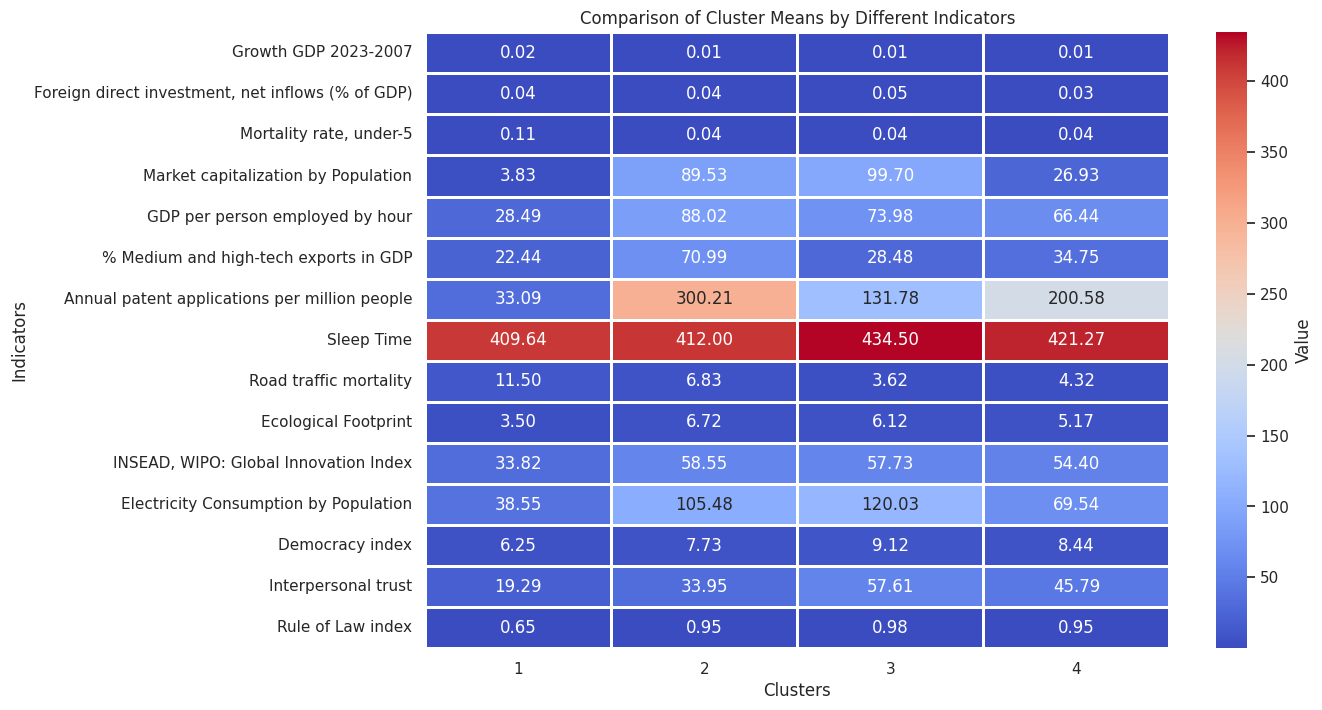

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Перелік країн для кожного кластеру
countries_cluster_1 = ['Albania', 'Argentina', 'Armenia', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Brazil',
                       'Bulgaria', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czechia', 'Egypt', 'Arab Rep.',
                       'Estonia', 'Georgia', 'Greece', 'Hungary', 'Indonesia', 'Kazakhstan', 'Latvia', 'Lithuania', 'Malaysia',
                       'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'New Zealand', 'North Macedonia', 'Panama',
                       'Paraguay', 'Peru', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovak Republic', 'Spain', 'Sri Lanka',
                       'Thailand', 'Tunisia', 'Turkiye', 'Ukraine', 'Uruguay']

countries_cluster_2 = ['Korea, Rep.', 'Luxembourg', 'Singapore', 'United States']

countries_cluster_3 = ['Australia', 'Canada', 'Netherlands', 'Norway', 'Sweden', 'Switzerland']

countries_cluster_4 = ['Austria', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland', 'Israel', 'Italy', 'Japan', 'Slovenia', 'United Kingdom']

# Додавання країн до кластеру в результатах
cluster_means_rounded['Countries'] = {
    1: countries_cluster_1,
    2: countries_cluster_2,
    3: countries_cluster_3,
    4: countries_cluster_4
}

# Візуалізація для порівняння показників між кластерами
# Створюємо графік для порівняння кластерів по кожному з показників

# Даний список показників для візуалізації
metrics = [
    'Growth GDP 2023-2007',
    'Foreign direct investment, net inflows (% of GDP)',
    'Mortality rate, under-5',
    'Market capitalization by Population',
    'GDP per person employed by hour',
    '% Medium and high-tech exports in GDP',
    'Annual patent applications per million people',
    'Sleep Time',
    'Road traffic mortality',
    'Ecological Footprint',
    'INSEAD, WIPO: Global Innovation Index',
    'Electricity Consumption by Population',
    'Democracy index',
    'Interpersonal trust',
    'Rule of Law index'
]

# Підготовка даних для візуалізації
cluster_means_rounded = cluster_means_rounded.drop(columns=['Countries'])  # Видаляємо колонку країн для візуалізації

# Підготовка графіку
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_rounded[metrics].transpose(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, cbar_kws={'label': 'Value'})

# Додавання заголовка та міток осей
plt.title('Comparison of Cluster Means by Different Indicators')
plt.xlabel('Clusters')
plt.ylabel('Indicators')
plt.show()


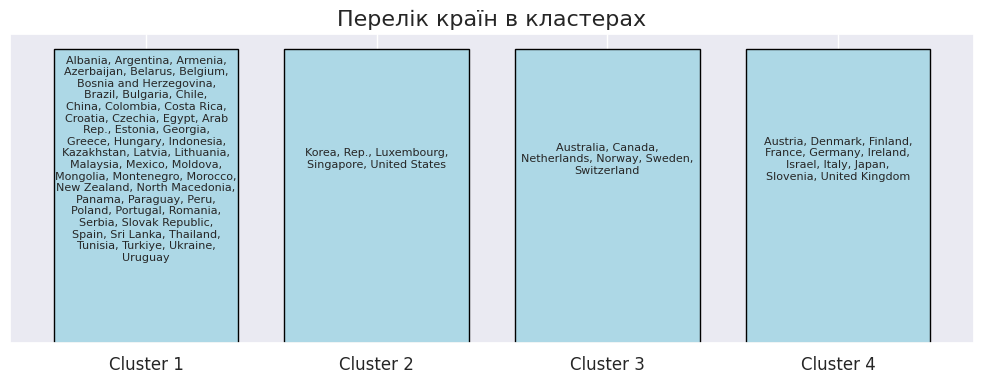

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# Список країн для кожного кластеру
countries_cluster_1 = ['Albania', 'Argentina', 'Armenia', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Brazil',
                       'Bulgaria', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czechia', 'Egypt', 'Arab Rep.',
                       'Estonia', 'Georgia', 'Greece', 'Hungary', 'Indonesia', 'Kazakhstan', 'Latvia', 'Lithuania', 'Malaysia',
                       'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'New Zealand', 'North Macedonia', 'Panama',
                       'Paraguay', 'Peru', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovak Republic', 'Spain', 'Sri Lanka',
                       'Thailand', 'Tunisia', 'Turkiye', 'Ukraine', 'Uruguay']
countries_cluster_2 = ['Korea, Rep.', 'Luxembourg', 'Singapore', 'United States']
countries_cluster_3 = ['Australia', 'Canada', 'Netherlands', 'Norway', 'Sweden', 'Switzerland']
countries_cluster_4 = ['Austria', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland', 'Israel', 'Italy', 'Japan', 'Slovenia', 'United Kingdom']

# Задаємо ширину для текстового блоку, щоб країни не виходили за межі
def format_countries_list(countries, width=30):
    countries_text = ', '.join(countries)
    return '\n'.join(textwrap.wrap(countries_text, width=width))

# Підготовка тексту з обмеженням ширини
formatted_clusters = [format_countries_list(countries_cluster_1),
                      format_countries_list(countries_cluster_2),
                      format_countries_list(countries_cluster_3),
                      format_countries_list(countries_cluster_4)]

# Створення графіку
fig, ax = plt.subplots(figsize=(10, 4))

# Визначення позицій для кожного стовпця
positions = np.arange(4)

# Створення стовпців
ax.bar(positions, [0.8] * 4, width=0.8, color='lightblue', edgecolor='black')

# Відображення країн у кожному стовпці з обмеженням ширини тексту
for i, text in enumerate(formatted_clusters):
    ax.text(positions[i], 0.5, text, ha='center', va='center', fontsize=8)

# Налаштування
ax.set_xticks(positions)
ax.set_xticklabels([f'Cluster {i+1}' for i in range(4)], fontsize=12)
ax.set_yticks([])
ax.set_title('Перелік країн в кластерах', fontsize=16)

# Відображення графіку
plt.tight_layout()
plt.show()


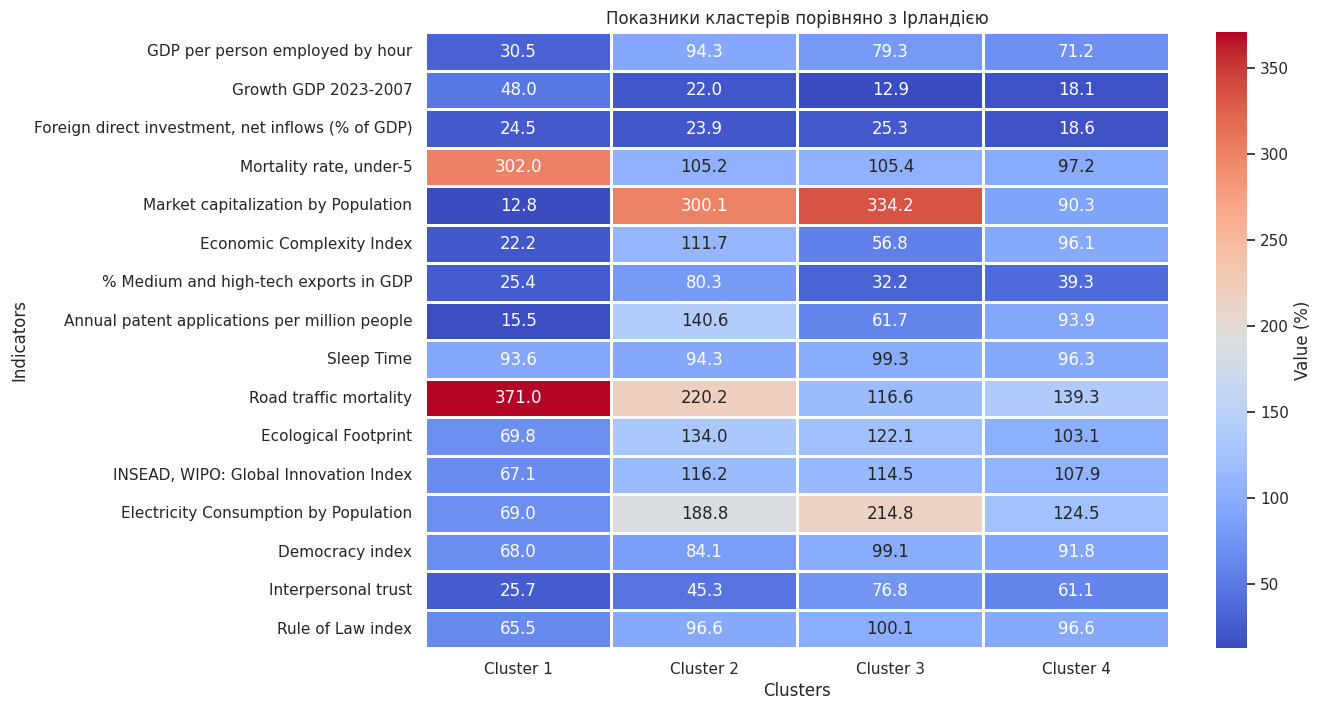

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Оновлені дані для кластерів
data = {
    'Metric': [
        'GDP per person employed by hour', 'Growth GDP 2023-2007',
        'Foreign direct investment, net inflows (% of GDP)', 'Mortality rate, under-5',
        'Market capitalization by Population', 'Economic Complexity Index',
        '% Medium and high-tech exports in GDP', 'Annual patent applications per million people',
        'Sleep Time', 'Road traffic mortality', 'Ecological Footprint',
        'INSEAD, WIPO: Global Innovation Index', 'Electricity Consumption by Population',
        'Democracy index', 'Interpersonal trust', 'Rule of Law index'
    ],
    'Cluster 1': [30.5, 48.0, 24.5, 302.0, 12.8, 22.2, 25.4, 15.5, 93.6, 371.0, 69.8, 67.1, 69.0, 68.0, 25.7, 65.5],
    'Cluster 2': [94.3, 22.0, 23.9, 105.2, 300.1, 111.7, 80.3, 140.6, 94.3, 220.2, 134.0, 116.2, 188.8, 84.1, 45.3, 96.6],
    'Cluster 3': [79.3, 12.9, 25.3, 105.4, 334.2, 56.8, 32.2, 61.7, 99.3, 116.6, 122.1, 114.5, 214.8, 99.1, 76.8, 100.1],
    'Cluster 4': [71.2, 18.1, 18.6, 97.2, 90.3, 96.1, 39.3, 93.9, 96.3, 139.3, 103.1, 107.9, 124.5, 91.8, 61.1, 96.6]
}

# Створення DataFrame
df = pd.DataFrame(data)
df.set_index('Metric', inplace=True)

# Побудова теплової карти
plt.figure(figsize=(12, 8))
sns.heatmap(df, annot=True, cmap='coolwarm', fmt='.1f', linewidths=1, cbar_kws={'label': 'Value (%)'})

# Додавання заголовка та міток осей
plt.title('Показники кластерів порівняно з Ірландією')
plt.xlabel('Clusters')
plt.ylabel('Indicators')

# Відображення графіка
plt.show()


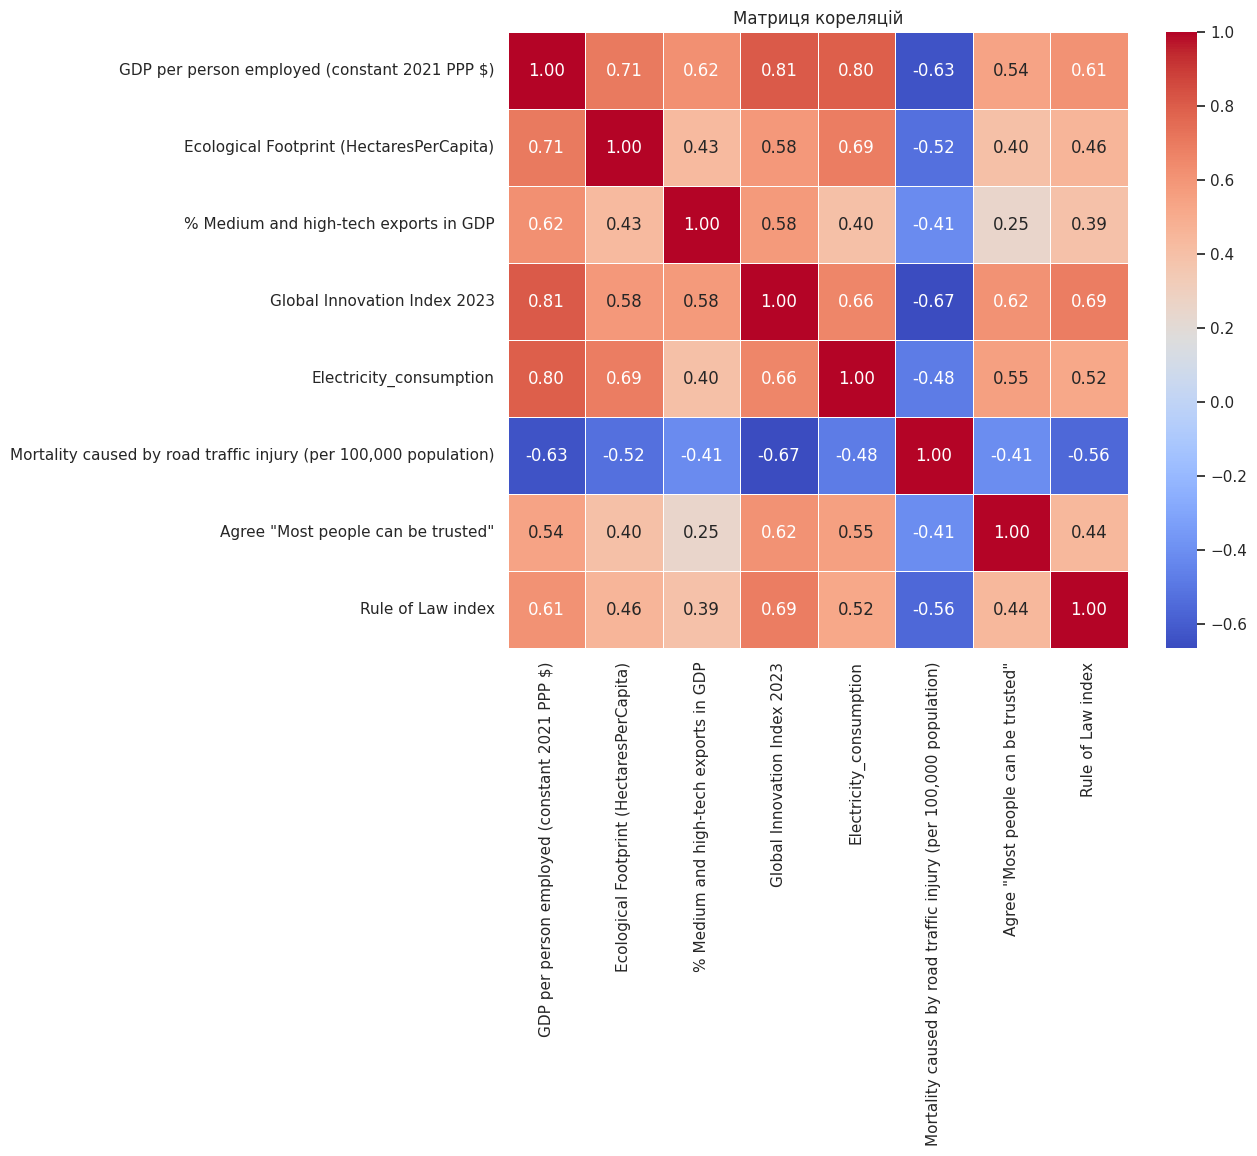

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_excel("Модель.xlsx")
data_numeric = data.drop(columns=["Country"])
correlation_matrix = data_numeric.corr()
sns.set(style="white")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матриця кореляцій')
plt.show()

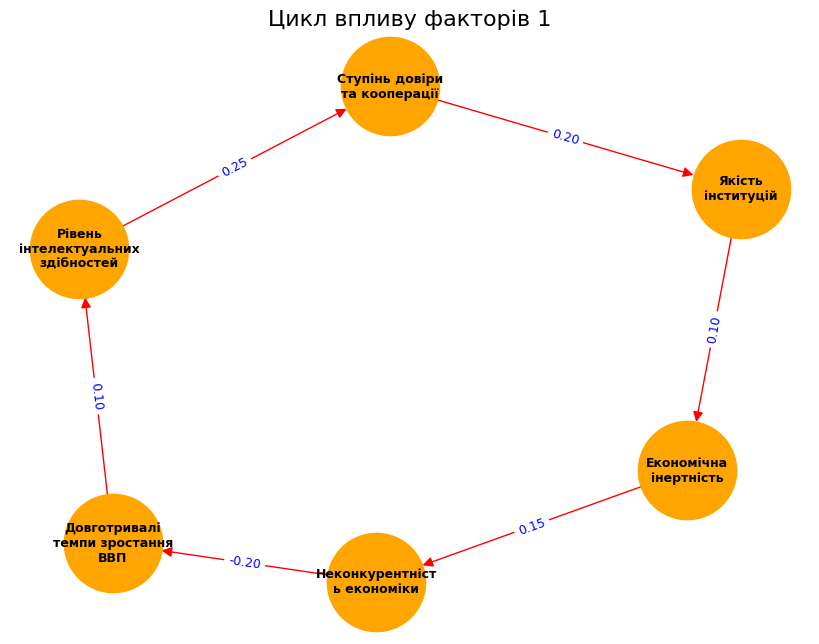

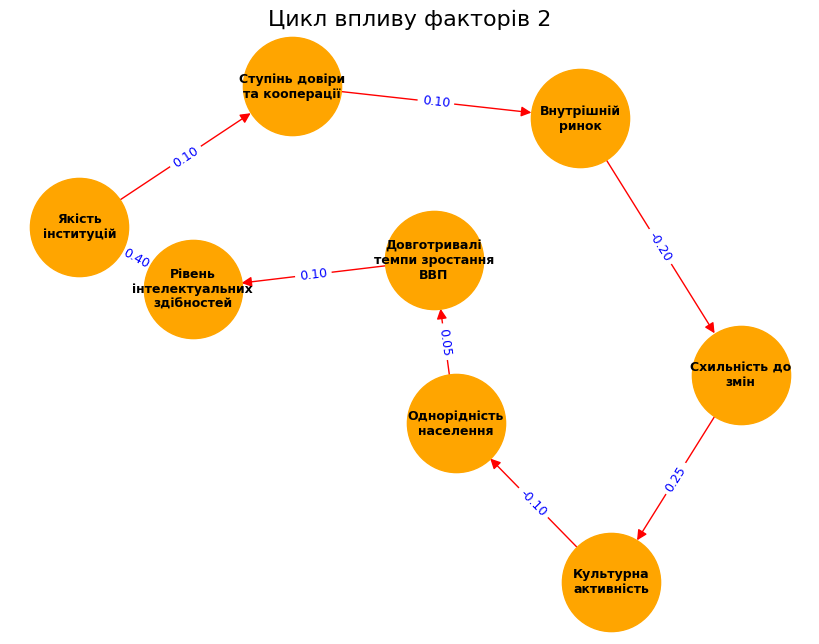

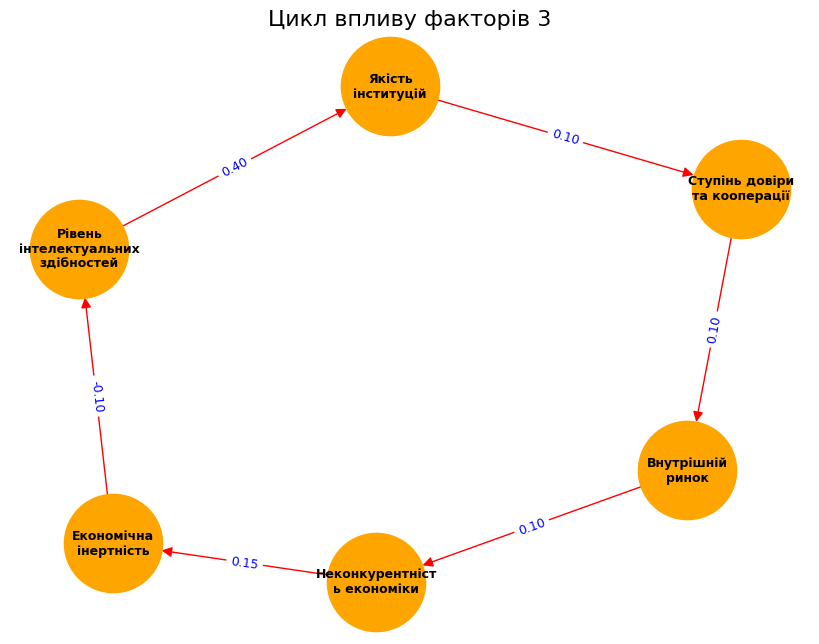

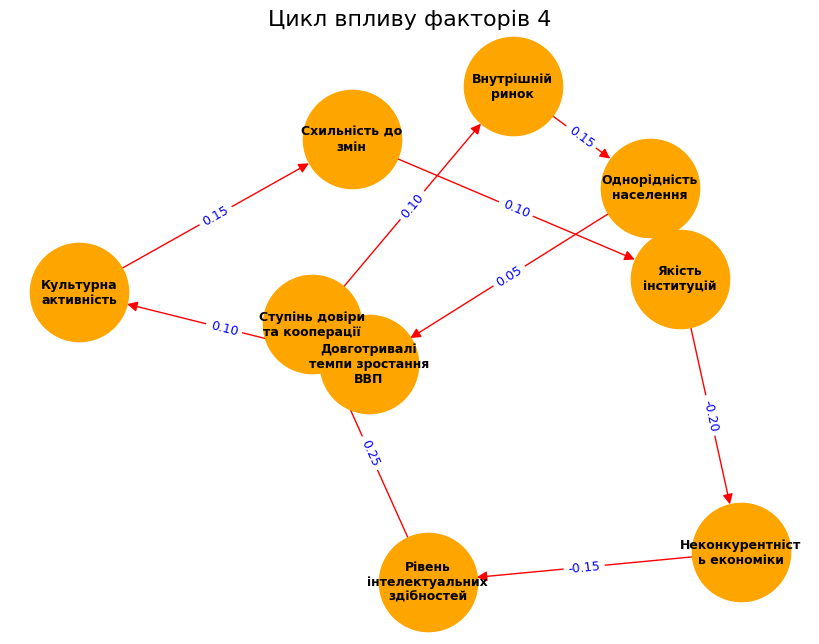

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import textwrap

# Словник для заміни кодів на назви факторів (додаємо перенос рядків)
factor_names = {
    'A': 'Довготривалі темпи зростання ВВП',
    'B': 'Рівень інтелектуальних здібностей',
    'C': 'Ступінь довіри та кооперації',
    'D': 'Якість інституцій',
    'E': 'Культурна активність',
    'F': 'Схильність до змін',
    'G': 'Економічна інертність',
    'H': 'Однорідність населення',
    'I': 'Внутрішній ринок',
    'J': 'Неконкурентність економіки'
}

# Правильні значення сили впливу для кожного ланцюга
impact_values = {
    0: [0.1, 0.25, 0.2, 0.1, 0.15, -0.2],
    1: [0.1, 0.1, -0.2, 0.25, -0.1, 0.05, 0.1, 0.4],
    2: [-0.1, 0.4, 0.1, 0.1, 0.1, 0.15],
    3: [0.15, 0.1, -0.2, -0.15, 0.25, 0.1, 0.15, 0.05, 0.1]
}

# Ланцюги з кодами факторів
chains = [
    ['A', 'B', 'C', 'D', 'G', 'J', 'A'],
    ['D', 'C', 'I', 'F', 'E', 'H', 'A', 'B', 'D'],
    ['G', 'B', 'D', 'C', 'I', 'J', 'G'],
    ['E', 'F', 'D', 'J', 'B', 'C', 'I', 'H', 'A', 'E']
]

# Замінюємо коди на відповідні назви для кожного ланцюга
named_chains = [[factor_names[node] for node in chain] for chain in chains]

# Створення графіків для кожного ланцюга
for i, chain in enumerate(chains):
    # Створення графа для поточного ланцюга
    G = nx.DiGraph()
    nx.add_path(G, chain)

    # Для четвертого ланцюга використовуємо позиціювання у формі багатогранника
    if i == 3:
        pos = nx.spring_layout(G, seed=42)  # Використовуємо spring_layout для багатогранника
    else:
        # Позиціонування вузлів для відображення
        pos = nx.spring_layout(G, seed=42)  # Для стабільного розташування

    # Створення окремого графіка
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=False, node_size=5000, node_color="orange", font_size=9, font_weight="bold", edge_color="red", arrows=True, arrowstyle='-|>', arrowsize=15)

    # Додавання сили впливу над стрілками з правильними значеннями
    edge_labels = {(chain[j], chain[j+1]): f"{impact_values[i][j]:.2f}" for j in range(len(chain)-1)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=9)

    # Налаштування розташування тексту в кружках
    labels = {node: '\n'.join(textwrap.wrap(factor_names[node], width=15)) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight="bold")

    # Додавання заголовку для кожного графіка
    plt.title(f"Цикл впливу факторів {i+1}", fontsize=16)

    # Відображення графіка
    plt.show()

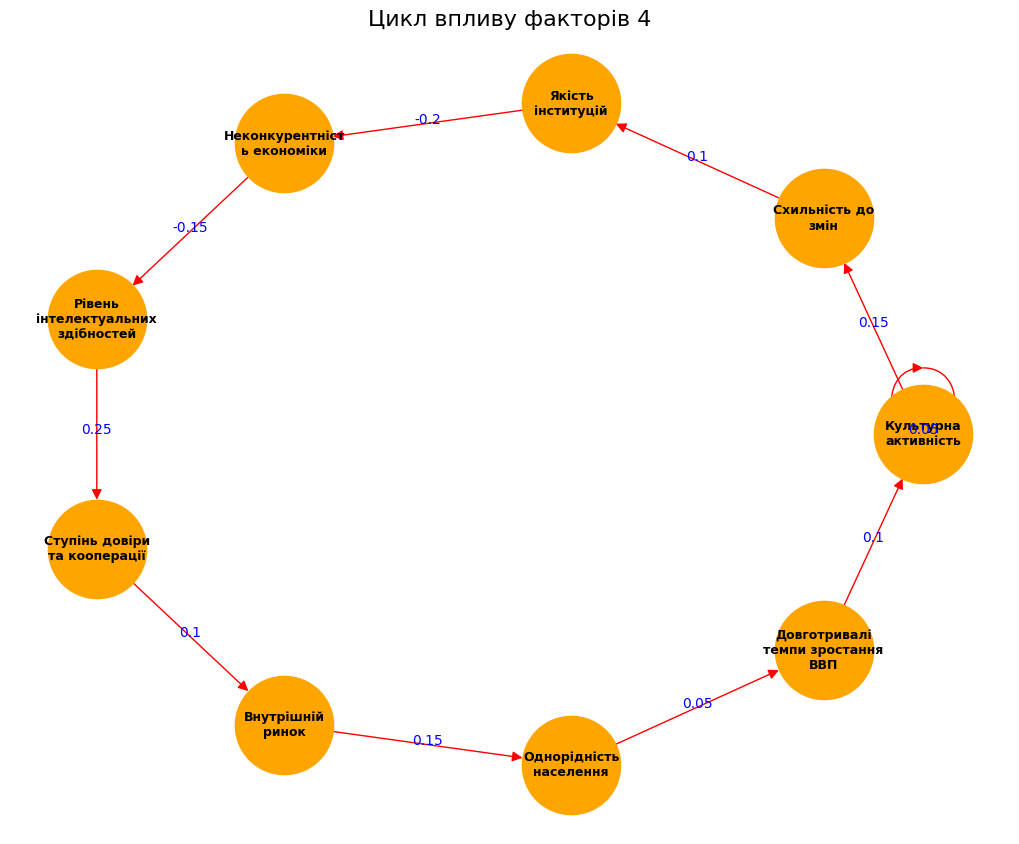

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import textwrap

# Словник для заміни кодів на назви факторів
factor_names = {
    'A': 'Довготривалі темпи зростання ВВП',
    'B': 'Рівень інтелектуальних здібностей',
    'C': 'Ступінь довіри та кооперації',
    'D': 'Якість інституцій',
    'E': 'Культурна активність',
    'F': 'Схильність до змін',
    'G': 'Економічна інертність',
    'H': 'Однорідність населення',
    'I': 'Внутрішній ринок',
    'J': 'Неконкурентність економіки'
}

# Ланцюг
chain = ['E', 'F', 'D', 'J', 'B', 'C', 'I', 'H', 'A', 'E']

# Значення впливу факторів (додано останнє значення для замкнення циклу)
influence_values = [0.15, 0.1, -0.2, -0.15, 0.25, 0.1, 0.15, 0.05, 0.1, 0.05]

# Створення графа для поточного ланцюга
G = nx.DiGraph()
nx.add_path(G, chain)

# Додавання останньої стрілки для замикання циклу
G.add_edge(chain[-1], chain[0])

# Використання circular_layout для розташування вузлів у колі
pos = nx.circular_layout(G)

# Створення графіка
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=False, node_size=5000, node_color="orange", font_size=9, font_weight="bold", edge_color="red", arrows=True, arrowstyle='-|>', arrowsize=15)

# Налаштування тексту в кружках
labels = {node: '\n'.join(textwrap.wrap(factor_names[node], width=15)) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight="bold")

# Додавання значень впливу над стрілками
for i, (start, end) in enumerate(zip(chain, chain[1:] + [chain[0]])):
    x_start, y_start = pos[start]
    x_end, y_end = pos[end]
    plt.text((x_start + x_end) / 2, (y_start + y_end) / 2, str(influence_values[i]),
             fontsize=10, ha='center', color='blue')

# Додавання заголовку для графіка
plt.title("Цикл впливу факторів 4", fontsize=16)

# Відображення графіка
plt.show()